# 05 – Robustness checks

No further tuning on Shakespeare: the configurations are exactly those selected on validation (LSTM 512×1, dropout 0.5; vanilla RNN 512×1, dropout 0.5).

1. **Seeds:** retrain both with seeds 1 and 2 (plus the original seed 42) and report test metrics as mean ± std over the 3 seeds.
2. **Paired bootstrap** over test *sentences* (1,000 resamples, seed-42 models, the same resampled sentences for both models of a pair) for 95 % confidence intervals of the differences, and **McNemar's test** on top-1 correctness for the thou / thee / thy / thine targets.
3. **Stateful latency:** keep the hidden state and feed only the newest token, as a real keyboard would, and compare with the stateless 7.3 ms.

Test-set note: the seed-1/2 models are *new* models, so scoring them on test is not a repeated use of the test set for tuning; the seed-42 models are re-scored (without logging) to get per-sentence and per-target statistics and are asserted to reproduce the logged numbers.

In [1]:
import sys, pickle, copy, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as D, evaluate as E, rnn as R, stats as S

FIG_DIR, TAB_DIR, MODEL_DIR = ROOT / "figures", ROOT / "tables", ROOT / "models"
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
BLUE, ORANGE, GREEN, GREY = "#0072B2", "#D55E00", "#009E73", "#777777"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    print(f"saved figure -> figures/{name}")


def save_table(df, name, index=False):
    df.to_csv(TAB_DIR / name, index=index, encoding="utf-8")
    print(f"saved table  -> tables/{name}")


vocab = D.load_vocab()
V = len(vocab)
train = D.load_split("train", vocab=vocab)
val = D.load_split("val", vocab=vocab)
test = D.load_split("test", vocab=vocab)
METRICS = ROOT / "results" / "metrics.csv"
if METRICS.exists():                                    # drop earlier rows of this notebook (seed models)
    old = pd.read_csv(METRICS)
    old[~old["model"].astype(str).str.contains(r"_s[12]$")].to_csv(METRICS, index=False)


def mb(path):
    return Path(path).stat().st_size / 1e6


BEST = {"lstm": R.default_cfg(cell="lstm", hidden=512, layers=1, dropout=0.5),
        "rnn": R.default_cfg(cell="rnn", hidden=512, layers=1, dropout=0.5)}
final = pd.read_csv(TAB_DIR / "rnn_test_results.csv")
print(final[["model", "run", "ppl", "top1"]].round(4).to_string(index=False))

device: cuda


              model                            run      ppl   top1
          KN bigram                            kn2 147.3810 0.1077
         KN trigram                            kn3 134.6814 0.1261
        Vanilla RNN               rnn_h512_l1_d0.5 112.9411 0.1278
               LSTM              lstm_h512_l1_d0.5  97.5686 0.1387
Ensemble (LSTM+KN3) ensemble_lstm_h512_l1_d0.5+kn3  92.8408 0.1431


## 1. Three seeds (42, 1, 2)
Seeds control the initialisation, the dropout masks and the batch order. Seed-42 results are the ones already reported; seeds 1 and 2 were trained by `python -m src.train_seeds` with identical hyperparameters (early stopping on validation as before).

In [2]:
cols = ["ppl", "top1", "top3", "ksr", "archaic_top1"]
rows = []
kn_ref = pd.read_csv(TAB_DIR / "ngram_test_results.csv").set_index("model").loc["kn3"]
for kind, label in (("rnn", "Vanilla RNN"), ("lstm", "LSTM")):
    for seed in (42, 1, 2):
        cfg = {**BEST[kind], "seed": seed}
        name = R.run_name(cfg)
        model, ck = R.load_run(cfg, V, device)
        if seed == 42:
            r = final.set_index("run").loc[name]
            res = {c: float(r[c]) for c in cols}
        else:
            pred = R.RNNPredictor(model, device, name=name, cfg=cfg)
            res = E.evaluate(pred, "test", vocab, log=True,
                             extra={"params": ck["num_params"], "size_mb": round(mb(MODEL_DIR / f"{name}.pt"), 2)})
            res = {c: float(res[c]) for c in cols}
        rows.append({"model": label, "seed": seed, "run": name, "best_epoch": ck["best_epoch"],
                     "val_ppl": ck["best_val_ppl"], **res})
per_seed = pd.DataFrame(rows)
display(per_seed.round(4))
save_table(per_seed, "robust_seeds_per_run.csv")

agg = per_seed.groupby("model")[["val_ppl"] + cols].agg(["mean", "std"])          # std: sample std (ddof = 1)
summary = pd.DataFrame({"model": agg.index})
for c in ["val_ppl"] + cols:
    summary[c] = [f"{m:.2f} ± {s:.2f}" if c in ("ppl", "val_ppl") else f"{100 * m:.2f} ± {100 * s:.2f} %" for m, s in zip(agg[(c, "mean")], agg[(c, "std")])]
display(summary)
save_table(summary, "robust_seeds_summary.csv")
print("std = sample standard deviation over the 3 seeds. KN trigram (deterministic, for reference):",
      {c: round(float(kn_ref[c]), 4) for c in cols})

,model,seed,run,best_epoch,val_ppl,ppl,top1,top3,ksr,archaic_top1
0,Vanilla RNN,42,rnn_h512_l1_d0.5,13,116.5464,112.9411,0.1278,0.2292,0.4876,0.0843
1,Vanilla RNN,1,rnn_h512_l1_d0.5_s1,19,115.5140,112.1558,0.1303,0.2341,0.4896,0.0913
2,Vanilla RNN,2,rnn_h512_l1_d0.5_s2,19,115.9797,112.2386,0.1307,0.2343,0.4897,0.0910
3,LSTM,42,lstm_h512_l1_d0.5,13,99.8526,97.5686,0.1387,0.2482,0.4977,0.0985
4,LSTM,1,lstm_h512_l1_d0.5_s1,15,99.7210,97.4191,0.1404,0.2503,0.4986,0.1085
5,LSTM,2,lstm_h512_l1_d0.5_s2,18,99.9122,97.3856,0.1423,0.2521,0.4994,0.1149


saved table  -> tables/robust_seeds_per_run.csv


,model,val_ppl,ppl,top1,top3,ksr,archaic_top1
0,LSTM,99.83 ± 0.10,97.46 ± 0.10,14.05 ± 0.18 %,25.02 ± 0.19 %,49.86 ± 0.09 %,10.73 ± 0.83 %
1,Vanilla RNN,116.01 ± 0.52,112.45 ± 0.43,12.96 ± 0.16 %,23.26 ± 0.29 %,48.90 ± 0.12 %,8.88 ± 0.40 %


saved table  -> tables/robust_seeds_summary.csv
std = sample standard deviation over the 3 seeds. KN trigram (deterministic, for reference): {'ppl': 134.6814, 'top1': 0.1261, 'top3': 0.2246, 'ksr': 0.4771, 'archaic_top1': 0.0651}


saved figure -> figures/robust_seeds.png


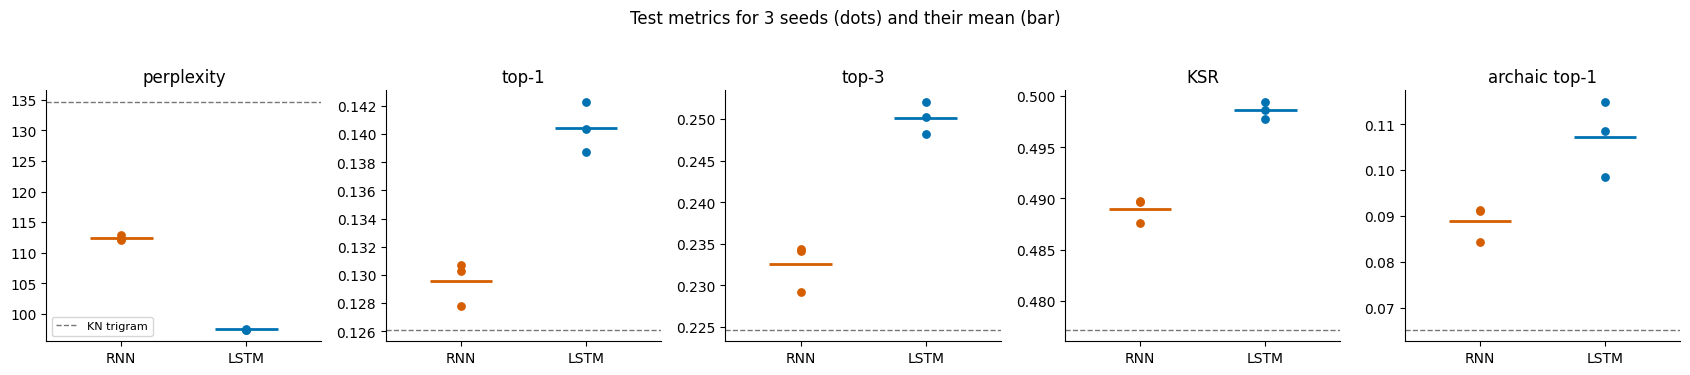

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.6))
for ax, c, t in zip(axes, cols, ["perplexity", "top-1", "top-3", "KSR", "archaic top-1"]):
    for x, (label, color) in enumerate((("Vanilla RNN", ORANGE), ("LSTM", BLUE))):
        v = per_seed[per_seed["model"] == label][c].values
        ax.scatter(np.full(3, x), v, color=color, s=28, zorder=3)
        ax.hlines(v.mean(), x - 0.25, x + 0.25, color=color, lw=2)
    ax.axhline(float(kn_ref[c]), color=GREY, ls="--", lw=1, label="KN trigram")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["RNN", "LSTM"]); ax.set_xlim(-0.6, 1.6); ax.set_title(t)
axes[0].legend(fontsize=8)
plt.suptitle("Test metrics for 3 seeds (dots) and their mean (bar)", y=1.03)
plt.tight_layout(); save_fig(fig, "robust_seeds.png"); plt.show()

## 2. Paired bootstrap and McNemar (seed-42 models, test set)
For each model we collect per-token log-probabilities and per-word-target ranks/keystrokes on the test set, aggregate them **per sentence**, and resample sentences with replacement 1,000 times; the *same* resampled sentences are used for both models of a pair, so the interval reflects the paired difference. Differences are A − B (negative perplexity difference = A is better). Archaic top-1 = archaic-keyword targets; the thou-family = `thou, thee, thy, thine`.

In [4]:
kn3 = pickle.load(open(MODEL_DIR / "kn3.pkl", "rb"))
lstm_cfg = BEST["lstm"]
lstm_model, _ = R.load_run(lstm_cfg, V, device)
lstm = R.RNNPredictor(lstm_model, device, name=R.run_name(lstm_cfg), cfg=lstm_cfg)
lam = float(pd.read_csv(TAB_DIR / "rnn_ensemble_lambda.csv").sort_values("val_ppl").iloc[0]["lambda"])
ens = R.Interpolated(lstm, kn3, lam, name="ensemble")
print("ensemble lambda (chosen on validation):", lam)

det = {}
for key, model in (("KN trigram", kn3), ("LSTM", lstm), ("Ensemble", ens)):
    r = E.evaluate(model, "test", vocab, log=False, details=True)
    det[key] = r.pop("details")
    ref = final.set_index("model").loc[{"KN trigram": "KN trigram", "LSTM": "LSTM", "Ensemble": "Ensemble (LSTM+KN3)"}[key]]
    for c in ("ppl", "top1", "top3", "ksr", "archaic_top1"):
        assert abs(r[c] - float(ref[c])) < 1e-6, (key, c, r[c], ref[c])
print("seed-42 models reproduce the logged test numbers")
assert all((det["LSTM"]["target"] == det[k]["target"]).all() for k in det)         # same targets in the same order

thou_ids = [vocab.stoi[w] for w in ("thou", "thee", "thy", "thine")]
groups = {k: {"thou": np.isin(d["target"], thou_ids)} for k, d in det.items()}
n_sent = len(test)
tabs = {k: S.sentence_table(d, n_sent, groups[k]) for k, d in det.items()}
print(f"{n_sent:,} test sentences; thou-family word targets: {int(groups['LSTM']['thou'].sum()):,}")

ensemble lambda (chosen on validation): 0.8


seed-42 models reproduce the logged test numbers
7,191 test sentences; thou-family word targets: 1,677


,comparison,metric,A,B,diff_A_minus_B,ci95_low,ci95_high,rel_diff_pct,ci_excludes_0
0,LSTM vs KN trigram,perplexity,97.5686,134.6814,-37.1128,-38.4465,-35.7267,-27.5560,True
1,LSTM vs KN trigram,top-1,0.1387,0.1261,0.0126,0.0107,0.0145,10.0068,True
2,LSTM vs KN trigram,KSR,0.4977,0.4771,0.0206,0.0196,0.0216,4.3169,True
3,LSTM vs KN trigram,archaic top-1,0.0985,0.0651,0.0334,0.0249,0.0412,51.2397,True
4,LSTM vs KN trigram,top-1 on thou/thee/thy/thine,0.1860,0.1240,0.0620,0.0459,0.0783,50.0000,True
5,Ensemble vs LSTM,perplexity,92.8408,97.5686,-4.7277,-5.0203,-4.4392,-4.8456,True
6,Ensemble vs LSTM,archaic top-1,0.0948,0.0985,-0.0038,-0.0075,-0.0003,-3.8251,True


saved table  -> tables/robust_bootstrap.csv


saved figure -> figures/robust_bootstrap_ci.png


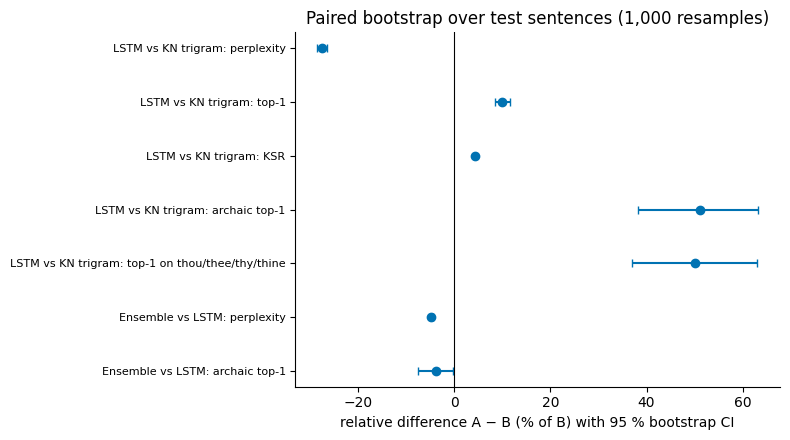

In [5]:
comparisons = [("LSTM vs KN trigram", "LSTM", "KN trigram", ["ppl", "top1", "ksr", "archaic_top1", "group:thou"]),
               ("Ensemble vs LSTM", "Ensemble", "LSTM", ["ppl", "archaic_top1"])]
label = {"ppl": "perplexity", "top1": "top-1", "ksr": "KSR", "archaic_top1": "archaic top-1", "group:thou": "top-1 on thou/thee/thy/thine"}
rows = []
for title, a, b, metrics in comparisons:
    res = S.paired_bootstrap(tabs[a], tabs[b], metrics, n_boot=1000, seed=42)
    for m, r in res.items():
        rows.append({"comparison": title, "metric": label[m], "A": r["a"], "B": r["b"], "diff_A_minus_B": r["diff"],
                     "ci95_low": r["ci_low"], "ci95_high": r["ci_high"], "rel_diff_pct": r["rel_diff_pct"],
                     "ci_excludes_0": r["significant"]})
boot = pd.DataFrame(rows)
display(boot.round(4))
save_table(boot, "robust_bootstrap.csv")

fig, ax = plt.subplots(figsize=(8, 4.5))
ylabels = []
for i, r in boot.iterrows():
    rel = lambda v: 100 * v / r["B"]
    ax.errorbar(rel(r["diff_A_minus_B"]), -i, xerr=[[rel(r["diff_A_minus_B"] - r["ci95_low"])], [rel(r["ci95_high"] - r["diff_A_minus_B"])]],
                fmt="o", color=BLUE if r["ci_excludes_0"] else GREY, capsize=3)
    ylabels.append(f"{r['comparison']}: {r['metric']}")
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(-np.arange(len(boot))); ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xlabel("relative difference A − B (% of B) with 95 % bootstrap CI")
ax.set_title("Paired bootstrap over test sentences (1,000 resamples)")
plt.tight_layout(); save_fig(fig, "robust_bootstrap_ci.png"); plt.show()

In [6]:
# McNemar on top-1 correctness for the thou-family targets (LSTM vs KN trigram)
m = groups["LSTM"]["thou"]
ok_l, ok_k = det["LSTM"]["rank"][m] == 1, det["KN trigram"]["rank"][m] == 1
mc = S.mcnemar(ok_l, ok_k)
mc_df = pd.DataFrame([{"targets": "thou / thee / thy / thine", "n": int(m.sum()),
                       "both_correct": mc["both"], "only_LSTM_correct": mc["only_a"], "only_KN3_correct": mc["only_b"],
                       "neither": mc["neither"], "p_exact": mc["p_exact"], "chi2_cc": mc["chi2"], "p_chi2": mc["p_chi2"]}])
display(mc_df)
save_table(mc_df, "robust_mcnemar.csv")
print(f"LSTM top-1 {ok_l.mean():.3f} vs KN-3 {ok_k.mean():.3f} on {int(m.sum())} thou-family targets; "
      f"exact McNemar p = {mc['p_exact']:.2e}")

,targets,n,both_correct,only_LSTM_correct,only_KN3_correct,neither,p_exact,chi2_cc,p_chi2
0,thou / thee / thy / thine,1677,171,141,37,1328,1.678078e-15,59.601124,1.161688e-14


saved table  -> tables/robust_mcnemar.csv
LSTM top-1 0.186 vs KN-3 0.124 on 1677 thou-family targets; exact McNemar p = 1.68e-15


## 3. Stateful vs stateless LSTM latency (CPU)
*Stateless* (what the evaluator and the 7.3 ms figure measure): every call re-reads the whole prefix from a zero state. *Stateful* (a real keyboard): keep (h, c) and feed only the newest token. Both are measured on the same positions of 150 validation sentences, on CPU, including the softmax and the conversion to a numpy distribution; the first 20 calls are warm-up.

2,655 calls; max |p_stateful - p_stateless| = 1.3e-06


,prefix length,stateful_ms,stateless_ms,speed_up
0,all,4.36,7.66,1.76
1,1-5,4.21,4.85,1.15
2,6-10,4.38,7.15,1.63
3,11-20,4.42,8.72,1.97
4,21+,4.43,10.38,2.34


saved table  -> tables/robust_latency.csv
saved figure -> figures/robust_latency.png


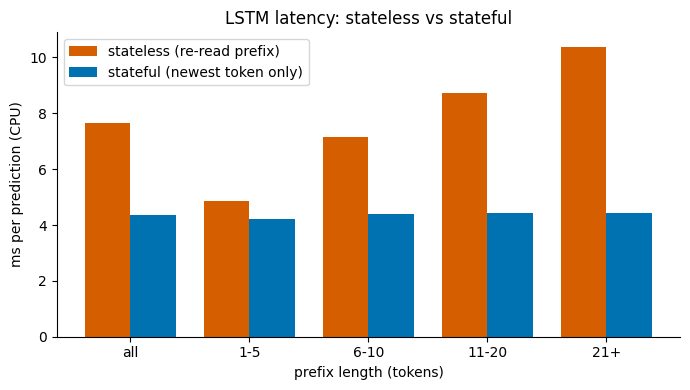

In [7]:
cpu_model = copy.deepcopy(lstm_model).cpu().eval()
cpu_pred = R.RNNPredictor(cpu_model, "cpu")
sess = R.RNNStateful(cpu_model)
sents = val[:150]
rows, max_diff = [], 0.0
perf = time.perf_counter
for s in sents:                                           # warm-up on the first sentences is dropped below
    sess.reset()
    for i in range(len(s) - 1):                           # prefix s[:i+1] -> distribution of s[i+1]
        t0 = perf(); p_sf = sess.step(s[i]); t_sf = perf() - t0
        t0 = perf(); p_sl = cpu_pred.next_word_probs(s[:i + 1]); t_sl = perf() - t0
        max_diff = max(max_diff, float(np.abs(p_sf - p_sl).max()))
        rows.append((i + 1, t_sf * 1000, t_sl * 1000))
lat = pd.DataFrame(rows[20:], columns=["prefix_len", "stateful_ms", "stateless_ms"])
print(f"{len(lat):,} calls; max |p_stateful - p_stateless| = {max_diff:.1e}")
bins = [(1, 5), (6, 10), (11, 20), (21, 10_000)]
out = [{"prefix length": "all", "stateful_ms": lat["stateful_ms"].mean(), "stateless_ms": lat["stateless_ms"].mean()}]
for lo, hi in bins:
    g = lat[(lat["prefix_len"] >= lo) & (lat["prefix_len"] <= hi)]
    out.append({"prefix length": f"{lo}-{hi}" if hi < 10_000 else f"{lo}+", "stateful_ms": g["stateful_ms"].mean(), "stateless_ms": g["stateless_ms"].mean()})
lat_df = pd.DataFrame(out)
lat_df["speed_up"] = lat_df["stateless_ms"] / lat_df["stateful_ms"]
display(lat_df.round(2))
save_table(lat_df.round(3), "robust_latency.csv")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(lat_df)); w = 0.38
ax.bar(x - w / 2, lat_df["stateless_ms"], w, color=ORANGE, label="stateless (re-read prefix)")
ax.bar(x + w / 2, lat_df["stateful_ms"], w, color=BLUE, label="stateful (newest token only)")
ax.set_xticks(x); ax.set_xticklabels(lat_df["prefix length"]); ax.set_xlabel("prefix length (tokens)"); ax.set_ylabel("ms per prediction (CPU)")
ax.set_title("LSTM latency: stateless vs stateful"); ax.legend()
plt.tight_layout(); save_fig(fig, "robust_latency.png"); plt.show()

## Summary of findings

1. **Seed stability (test, mean ± sample std over seeds 42, 1, 2):** LSTM perplexity **97.46 ± 0.10**, top-1 14.05 ± 0.18 %, top-3 25.02 ± 0.19 %, KSR 49.86 ± 0.09 %, archaic top-1 10.73 ± 0.83 %; vanilla RNN 112.45 ± 0.43, 12.96 ± 0.16 %, 23.26 ± 0.29 %, 48.90 ± 0.12 %, 8.88 ± 0.40 %. Seed-to-seed variation is tiny compared with the gaps between models: every LSTM seed beats the (deterministic) KN trigram on every metric, and every RNN seed beats it on perplexity (112 vs 134.7) while its top-1 advantage (12.96 vs 12.61 %) is only about two standard deviations.
2. **The seed-42 numbers reported earlier are slightly conservative for the LSTM:** its archaic top-1 (9.85 %) is the lowest of the three seeds (10.85 %, 11.49 %); archaic top-1 is the noisiest metric (std 0.8 points, on ~3.7k targets).
3. **LSTM vs KN trigram (paired bootstrap over 7,191 test sentences, 1,000 resamples, 95 % CI of A − B):** perplexity −37.1 [−38.4, −35.7] (−27.6 %); top-1 +1.26 [+1.07, +1.45] points; KSR +2.06 [+1.96, +2.16] points; archaic top-1 +3.34 [+2.49, +4.12] points. None of the intervals contains 0.
4. **thou / thee / thy / thine (1,677 targets):** top-1 18.6 % vs 12.4 %, difference +6.2 points, CI [+4.6, +7.8]. McNemar's test on top-1 correctness: the LSTM is right where the KN trigram is wrong 141 times, the reverse only 37 times (171 both right, 1,328 both wrong), exact p = 1.7e-15 (continuity-corrected χ² = 59.6). The LSTM's advantage on the archaic pronouns is statistically very clear.
5. **Ensemble vs LSTM:** perplexity −4.73 [−5.02, −4.44] (−4.8 %), a clear gain; archaic top-1 −0.38 [−0.75, −0.03] points, i.e. the ensemble is marginally *worse* on archaic words (the interval only just excludes 0), consistent with the KN component diluting archaic predictions.
6. **Stateful latency (CPU, same 2,655 positions):** keeping the hidden state costs **4.4 ms per prediction independent of the prefix length**, versus 7.7 ms stateless (4.9 ms for prefixes of 1–5 tokens, 10.4 ms beyond 20): a 1.8× speed-up overall and 2.3× for long prefixes. The saving is smaller than one might expect because most of the cost is the output layer (a 14.7k × 512 matrix product and softmax over the whole vocabulary), not the recurrence; stateful predictions equal the stateless ones to 1.3e-6.
7. **Caveats:** three seeds give a rough, not a precise, estimate of the variance (std of 3 values); the bootstrap resamples sentences of one test set and a single set of trained models, so it captures test-sample variability, not training variability (that is what the seeds are for); latency is a single-machine CPU wall-clock measurement.